# 1. Import libraries and data

In [27]:
# Basic Libraries
import numpy as np
import pandas as pd

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Date handling
from datetime import datetime

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import AgglomerativeClustering

# Dimensionality Reduction (Optional for visualization)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Evaluation
from sklearn.metrics import silhouette_score

In [28]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [29]:
df = pd.read_csv('D:\STATA và PYTHON\LAB03\OnlineRetail.csv', encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [31]:
df.shape

(541909, 8)

# 2.Data Preprocessing

In [32]:
# Remove rows with missing CustomerID
df= df[df.CustomerID.notnull()]
# Remove rows with missing CustomerID
df = df[df['CustomerID'].notnull()]
print(f"Shape after removing null CustomerIDs: {df.shape}")
df.sample(5)

Shape after removing null CustomerIDs: (406829, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
404519,571679,22996,TRAVEL CARD WALLET VINTAGE TICKET,6,18-10-2011 13:41,0.42,14159.0,United Kingdom
375948,569488,22737,RIBBON REEL CHRISTMAS PRESENT,5,04-10-2011 13:10,1.65,16440.0,United Kingdom
127064,547194,22895,SET OF 2 TEA TOWELS APPLE AND PEARS,1,21-03-2011 12:42,2.95,12637.0,France
499790,578695,20668,DISCO BALL CHRISTMAS DECORATION,48,25-11-2011 09:42,0.12,13199.0,United Kingdom
299507,563100,23297,SET 40 HEART SHAPE PETIT FOUR CASES,16,12-08-2011 09:57,1.65,12381.0,Norway


In [33]:
InvoiceNo_C= df[df['InvoiceNo'].astype(str).str.startswith('C')]
InvoiceNo_C.sample(6)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
382893,C569970,23240,SET OF 4 KNICK KNACK TINS DOILY,-2,06-10-2011 18:57,4.15,13055.0,United Kingdom
215717,C555729,23093,SMALL PARISIENNE HEART PHOTO FRAME,-1,06-06-2011 16:50,2.49,13552.0,United Kingdom
392671,C570708,M,Manual,-600,12-10-2011 10:11,0.19,12908.0,United Kingdom
352740,C567681,23208,LUNCH BAG VINTAGE LEAF DESIGN,-2,21-09-2011 16:24,1.65,15433.0,United Kingdom
481905,C577384,21313,GLASS HEART T-LIGHT HOLDER,-10,18-11-2011 16:50,0.64,14156.0,EIRE
383063,C569994,22727,ALARM CLOCK BAKELIKE RED,-20,06-10-2011 20:33,3.75,15606.0,United Kingdom


In [34]:
# Remove canceled transactions (usually credit memos)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [35]:
# Check 
df[df['InvoiceNo'].astype(str).str.startswith('C')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [36]:
# Remove negative quantities or prices
df= df[(df['Quantity']> 0 ) & (df['UnitPrice'] > 0 )]

In [37]:
# Convert InvoiceDate to datetime

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst= True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.3+ MB


In [38]:
# Create TotalPrice 
df['TotalPrice']= df['UnitPrice']* df['Quantity']
df.sample(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
447834,574965,22434,BALLOON PUMP WITH 10 BALLOONS,1,2011-11-08 10:44:00,1.95,17964.0,United Kingdom,1.95
6509,536946,22452,MEASURING TAPE BABUSHKA PINK,6,2010-12-03 12:28:00,2.95,13013.0,United Kingdom,17.70
523222,580504,23579,SNACK TRAY I LOVE LONDON,1,2011-12-04 13:32:00,1.95,17936.0,United Kingdom,1.95
420279,572885,22685,FRENCH BLUE METAL DOOR SIGN 0,2,2011-10-26 13:45:00,1.25,15311.0,United Kingdom,2.50
158762,550313,23155,KNICKERBOCKERGLORY MAGNET ASSORTED,24,2011-04-17 11:21:00,0.83,12681.0,France,19.92


In [39]:
# Group by country and calculate total purchase and unique customer count
country_summary = df.groupby('Country').agg(
    total_purchase=('TotalPrice', 'sum'),   # Total amount spent per country
    unique_customers=('CustomerID', 'nunique')  # Count of unique customers per country
).reset_index()

# Sort by total_purchase in descending order
country_summary = country_summary.sort_values(by='total_purchase', ascending=False)

# Show the results
print(f'What countries we have and how much purchase for each one: \n \n {country_summary}')

What countries we have and how much purchase for each one: 
 
                  Country  total_purchase  unique_customers
35        United Kingdom     7308391.554              3920
23           Netherlands      285446.340                 9
10                  EIRE      265545.900                 3
14               Germany      228867.140                94
13                France      209024.050                87
0              Australia      138521.310                 9
30                 Spain       61577.110                30
32           Switzerland       56443.950                21
3                Belgium       41196.340                25
31                Sweden       38378.330                 8
19                 Japan       37416.370                 8
24                Norway       36165.440                10
26              Portugal       33439.890                19
12               Finland       22546.080                12
29             Singapore       21279.290            

# 3. Data Prepration

In [40]:
# Set a Reference Date
latest_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Group by CustomerID and Calculate RFM Features
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days,   # Recency
    'InvoiceNo': 'nunique',                                  # Frequency
    'TotalPrice': 'sum'                                      # Monetary
})
#  Rename the Columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [41]:
rfm.sample(3)

,Recency,Frequency,Monetary
CustomerID,,,
15975.0,84,1,371.01
13516.0,21,3,1389.41
14562.0,4,18,5074.77


3.1 Standardize RFM values

In [42]:
# Keep a copy of the original RFM
rfm_original = rfm.copy()

# Standardize (important for clustering)
scaler= StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# Convert back to DataFrame for easier handling
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)
rfm_scaled_df.head()


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.358668
12347.0,-0.905340,0.354417,0.250966
12348.0,-0.175360,-0.035340,-0.028596
12349.0,-0.735345,-0.425097,-0.033012
12350.0,2.174578,-0.425097,-0.191347


# 4. K-Means Clustering

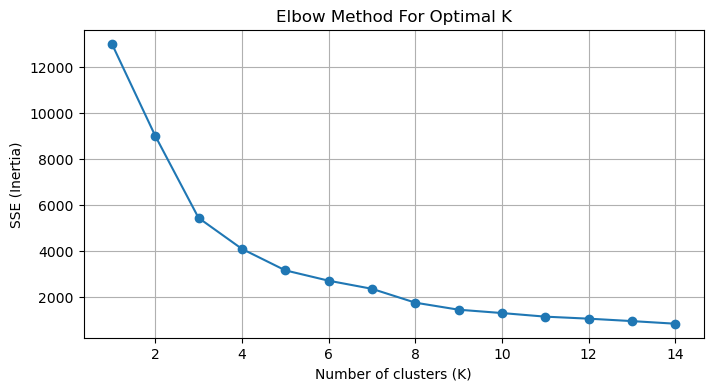

In [43]:
# Try different values of k to find the best one

sss= []
k_range= range(1,15)

for k in k_range: 
    kmeans= KMeans(n_clusters=k, random_state=10)
    kmeans.fit(rfm_scaled_df)
    sss.append(kmeans.inertia_)  # Inertia = within-cluster sum of squares

# Plot the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(k_range, sss, marker='o')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('SSE (Inertia)')
plt.grid(True)
plt.show()

In [44]:
# Apply KMeans with chosen K
Kmeans = KMeans(n_clusters=4, random_state=10)
rfm_scaled_df['KMeansCluster']= Kmeans.fit_predict(rfm_scaled_df)

# Add cluster to original RFM
rfm_original['KMeansCluster'] = rfm_scaled_df['KMeansCluster']

# Preview
rfm_original.groupby('KMeansCluster').mean()

,Recency,Frequency,Monetary
KMeansCluster,,,
0,15.672986,22.047393,12453.225924
1,248.564030,1.551789,478.107581
2,7.384615,82.538462,127338.313846
3,43.920380,3.656291,1350.140532


In [45]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# KMeans Evaluation
kmeans_labels = rfm_scaled_df['KMeansCluster']
print("K-Means Evaluation:")
print("Silhouette Score:", silhouette_score(rfm_scaled_df.drop('KMeansCluster', axis=1), kmeans_labels))
print("Davies-Bouldin Score:", davies_bouldin_score(rfm_scaled_df.drop('KMeansCluster', axis=1), kmeans_labels))
print("Calinski-Harabasz Index:", calinski_harabasz_score(rfm_scaled_df.drop('KMeansCluster', axis=1), kmeans_labels))

K-Means Evaluation:
Silhouette Score: 0.6160248190563382
Davies-Bouldin Score: 0.7523067593194316
Calinski-Harabasz Index: 3149.6594714850626


In [46]:
rfm_original.sample(10) 

,Recency,Frequency,Monetary,KMeansCluster
CustomerID,,,,
14871.0,3,4,522.38,3
15862.0,8,4,832.88,3
15720.0,24,1,598.73,3
15447.0,331,1,155.17,1
13870.0,2,8,2770.94,3
13476.0,179,2,1238.47,1
12814.0,102,1,125.92,3
17131.0,5,5,2463.17,3
17337.0,151,4,2027.87,1


# 5.Hierarchical Clustering

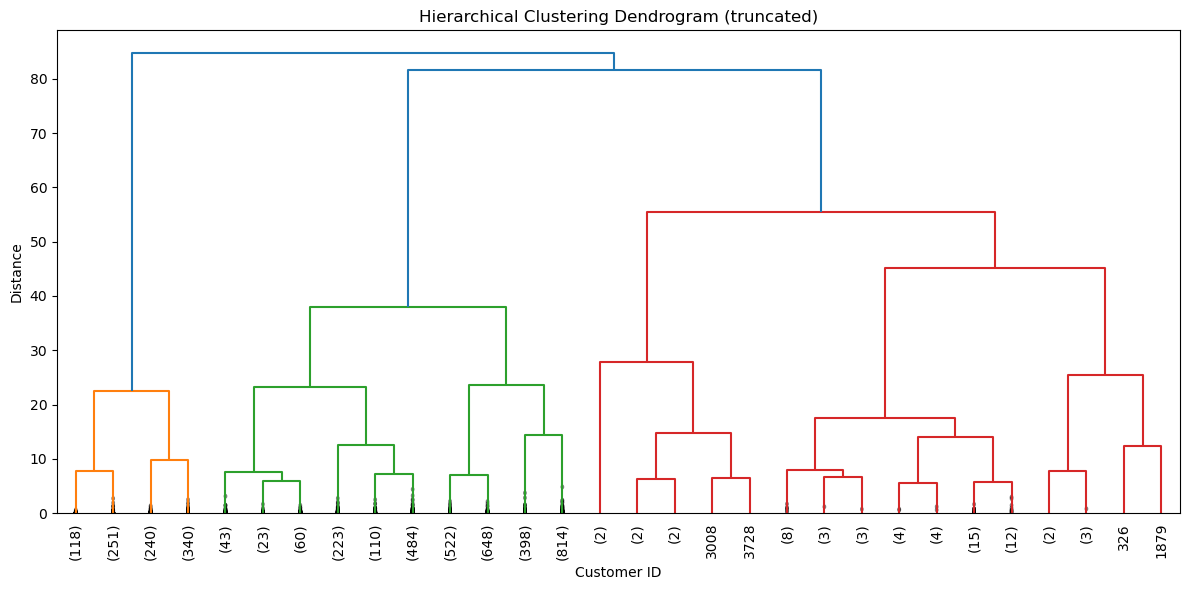

In [47]:
# Create linkage matrix
linked = linkage(rfm_scaled_df.drop('KMeansCluster', axis=1), method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (truncated)')
plt.xlabel('Customer ID')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [48]:
# Apply Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=4, linkage='ward')
rfm_scaled_df['HierarchicalCluster'] = agglo.fit_predict(rfm_scaled_df.drop('KMeansCluster', axis=1))

# Add to original RFM
rfm_original['HierarchicalCluster'] = rfm_scaled_df['HierarchicalCluster']

# View cluster means
rfm_original.groupby('HierarchicalCluster').mean()

,Recency,Frequency,Monetary,KMeansCluster
HierarchicalCluster,,,,
0,24.928571,43.785714,31348.385536,0.178571
1,11.000000,43.875000,164658.498750,2.000000
2,46.205414,4.305263,1625.457204,2.787669
3,259.542677,1.489989,457.307820,1.000000


In [49]:
# Hierarchical Evaluation
hier_labels = rfm_scaled_df['HierarchicalCluster']
print("\nHierarchical Clustering Evaluation:")
print("Silhouette Score:", silhouette_score(rfm_scaled_df.drop(['KMeansCluster', 'HierarchicalCluster'], axis=1), hier_labels))
print("Davies-Bouldin Score:", davies_bouldin_score(rfm_scaled_df.drop(['KMeansCluster', 'HierarchicalCluster'], axis=1), hier_labels))
print("Calinski-Harabasz Index:", calinski_harabasz_score(rfm_scaled_df.drop(['KMeansCluster', 'HierarchicalCluster'], axis=1), hier_labels))


Hierarchical Clustering Evaluation:
Silhouette Score: 0.6065329601634818
Davies-Bouldin Score: 0.7570399727948355
Calinski-Harabasz Index: 2677.9382739908083


# 6. Visualize the Clusters

In [50]:
# Create a dictionary to hold the metrics for each clustering algorithm
comparison_data = {
    'Metric': ['Silhouette Score', 'Davies-Bouldin Score', 'Calinski-Harabasz Index'],
    'K-Means': [
        silhouette_score(rfm_scaled_df.drop('KMeansCluster', axis=1), kmeans_labels),
        davies_bouldin_score(rfm_scaled_df.drop('KMeansCluster', axis=1), kmeans_labels),
        calinski_harabasz_score(rfm_scaled_df.drop('KMeansCluster', axis=1), kmeans_labels)
    ],
    'Hierarchical': [
        silhouette_score(rfm_scaled_df.drop(['KMeansCluster', 'HierarchicalCluster'], axis=1), hier_labels),
        davies_bouldin_score(rfm_scaled_df.drop(['KMeansCluster', 'HierarchicalCluster'], axis=1), hier_labels),
        calinski_harabasz_score(rfm_scaled_df.drop(['KMeansCluster', 'HierarchicalCluster'], axis=1), hier_labels)
    ]
}

# Convert to DataFrame for easy comparison
comparison_df = pd.DataFrame(comparison_data)

# Display the table
comparison_df

,Metric,K-Means,Hierarchical
0,Silhouette Score,0.636253,0.606533
1,Davies-Bouldin Score,0.773766,0.757040
2,Calinski-Harabasz Index,3215.971947,2677.938274


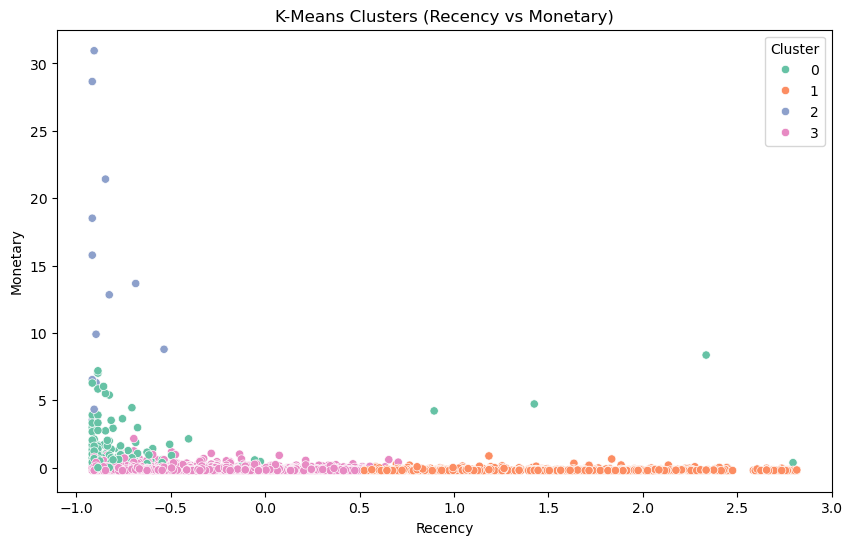

In [51]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm_scaled_df, x='Recency', y='Monetary', hue='KMeansCluster', palette='Set2')
plt.title('K-Means Clusters (Recency vs Monetary)')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.legend(title='Cluster')
plt.show()

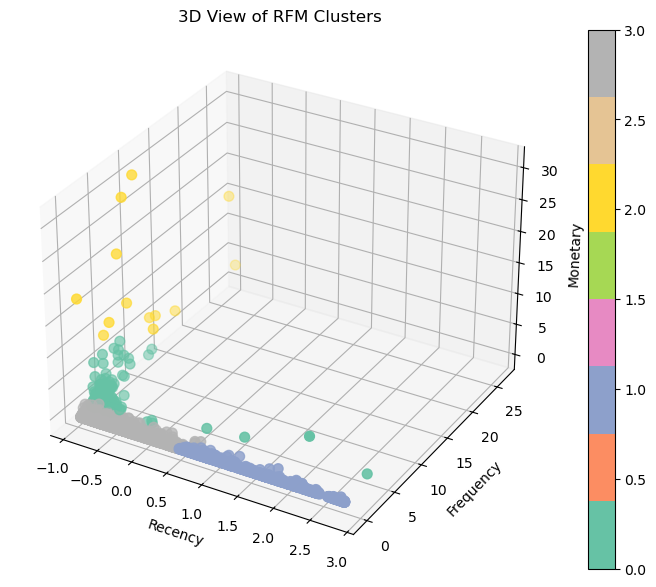

In [52]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    rfm_scaled_df['Recency'], 
    rfm_scaled_df['Frequency'], 
    rfm_scaled_df['Monetary'], 
    c=rfm_scaled_df['KMeansCluster'], 
    cmap='Set2', s=50
)

ax.set_title('3D View of RFM Clusters')
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
plt.colorbar(scatter)
plt.show()

Analyze Each Cluster

In [53]:
rfm_reset = rfm_original.reset_index()
rfm_reset.head()

,CustomerID,Recency,Frequency,Monetary,KMeansCluster,HierarchicalCluster
0,12346.0,326,1,77183.60,0,0
1,12347.0,2,7,4310.00,3,2
2,12348.0,75,4,1797.24,3,2
3,12349.0,19,1,1757.55,3,2
4,12350.0,310,1,334.40,1,3


In [54]:
# Keep KMeans clusters and drop hierarchical clusters
rfm_reset['Cluster'] = rfm_reset['KMeansCluster']  # Assign KMeans labels
rfm_reset= rfm_reset.drop(columns=['KMeansCluster',	'HierarchicalCluster'])

In [55]:
rfm_reset.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,0
1,12347.0,2,7,4310.00,3
2,12348.0,75,4,1797.24,3
3,12349.0,19,1,1757.55,3
4,12350.0,310,1,334.40,1


In [56]:
cluster_profile = rfm_reset.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'NumCustomers'})

In [57]:
cluster_profile.to_csv("cluster_summary.csv")
rfm_reset.to_csv("rfm_with_clusters.csv")

In [58]:
cluster_profile

,Recency,Frequency,Monetary,NumCustomers
Cluster,,,,
0,15.672986,22.047393,12453.225924,211
1,248.564030,1.551789,478.107581,1062
2,7.384615,82.538462,127338.313846,13
3,43.920380,3.656291,1350.140532,3052


# 6. Analyze the Clusters

In [59]:
# Manually mapping cluster numbers to names based on their profile
cluster_labels = {
    0: 'Low Value',
    1: 'Churned Big Spenders',
    2: 'Occasional Buyers',
    3: 'High Value'
}

# Add label column
rfm_reset['Segment'] = rfm_reset['Cluster'].map(cluster_labels)

In [60]:
rfm_reset.sample(5)

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
330,12753.0,23,6,21429.39,3,High Value
4295,18227.0,218,1,93.75,1,Churned Big Spenders
3254,16780.0,100,2,425.19,3,High Value
319,12736.0,333,1,234.00,1,Churned Big Spenders
2868,16249.0,53,5,1800.07,3,High Value


In [61]:
# Profile Clusters with Stats
segment_profile = rfm_reset.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'NumCustomers'}).round(2)

segment_profile

,Recency,Frequency,Monetary,NumCustomers
Segment,,,,
Churned Big Spenders,248.56,1.55,478.11,1062
High Value,43.92,3.66,1350.14,3052
Low Value,15.67,22.05,12453.23,211
Occasional Buyers,7.38,82.54,127338.31,13


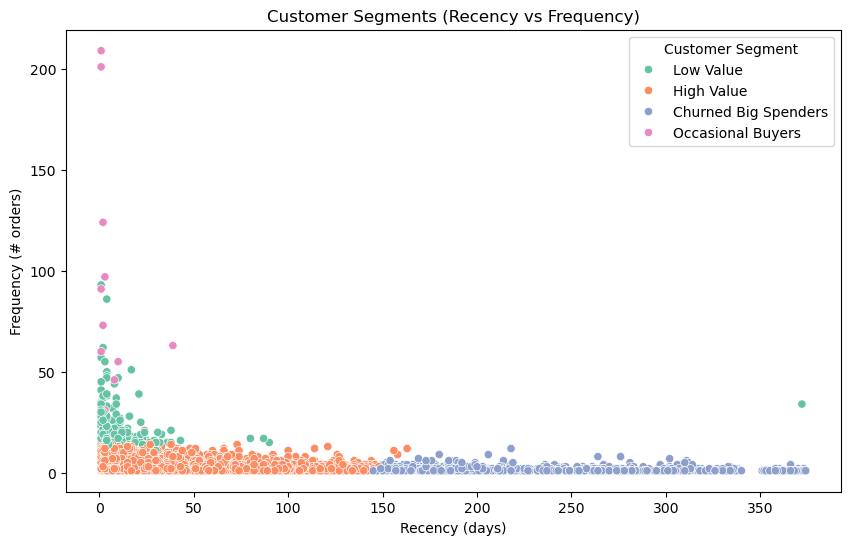

In [62]:
# Plot Clusters with 2D Scatter Plot (Recency vs Frequency)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=rfm_reset, x='Recency', y='Frequency', hue='Segment', palette='Set2'
)
plt.title('Customer Segments (Recency vs Frequency)')
plt.xlabel('Recency (days)')
plt.ylabel('Frequency (# orders)')
plt.legend(title='Customer Segment')
plt.show()